In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [2]:
from tensorflow.keras.utils import to_categorical  # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨 인식, 문장분류, 질병진단, (얼굴인식)...
- ML/DL의 종류
    - 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
        - 회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
    - 비지도학습(입력변수만)
        -군집분석(군집화)
    - 강화학습

※ 지도학습에서의 ML, DL 프로그램 방식
1. 데이터셋 확보(input=입력변수, target=종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련셋(학습셋), 검증셋, 시험셋(테스트셋) = 6: 2: 2 or 7: 2: 1 or 8 : 0 : 2
    학습 및 평가 가능한 포맷으로 변환(*numpy*, DataFrame)
3. 모델 구성
    Seqouetial 객체 생성 뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    copile() 함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델학습시키기 (ft. 학습과정 지켜보기)
    fit() 함수 이용 - 훈련셋입력 = 독립변수, 훈련셋타겟 = 종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프

# 1. 데이터셋 생성

In [3]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)


# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])

# 시험데이터 = 테스트셋
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((90,), (90,), (9,), (9,), (9,), (9,))

# 2. 데이터 전처리

In [4]:
# 인코딩 종류
data = np.array(['서울', '경기', '인천', '부산'])
print('원 데이터:', data)
from sklearn.preprocessing import LabelEncoder  # 특정한 문자를 숫자로 인코딩해줌
le = LabelEncoder()
# le.fit(data)
# labled_data = le.transform(data)
# 위 둘을 한번에 할 수 있다 -> le.fit_transform
labled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labled_data)
one_hot_encoded_data = to_categorical(labled_data)
print('원핫인코딩된 데이터 :', one_hot_encoded_data)

원 데이터: ['서울' '경기' '인천' '부산']
라벨인코딩된 데이터 : [2 0 3 1]
원핫인코딩된 데이터 : [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [5]:
# 분류분석을 위해, target을 원핫인코딩(리벨링 전환)

import pandas as pd
data = np.array([1,2,2,4,2])

categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n', categorical_one_hot)

get_dumies_one_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩 :', get_dumies_one_hot)

print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
y_train, Y_train

In [6]:
# 분류분석을 위한 target변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train, 19)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

In [ ]:
print('훈련셋 구조:', x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19개
print('검증셋 구조:', x_val.shape, Y_val.shape)
print('테스트셋 구조:', x_test.shape, Y_test.shape)

# 3. 모델 구성하기

In [7]:
model = Sequential()
model.add(Input(shape=(1,))) #입력층
model.add(Dense(units=38, activation='sigmoid')) # units은 출력수, 활성화 함수 : relu, tanh, sigmoid..
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))  
# 'softmax' : 모든 출력 결과의 합이 1. 분류분석 마지막 레이어(출력층)에서 활성화함수로 사용

In [ ]:
model.summary()

# 4. 모델 학습과정 설정

In [8]:
model.compile(loss="categorical_crossentropy", # 분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy'])

# 5. 모델 학습시키기

In [9]:
hist = model.fit(x_train, Y_train,
                epochs=300,
                batch_size=10,
                verbose=2, # 0: 출력없음, 1:기본값, 2:에포크별 상세출력
                validation_data= (x_val, Y_val) # 튜플 혹은 리스트 둘다 가능
                )

Epoch 1/300
9/9 - 1s - loss: 3.0458 - accuracy: 0.0333 - val_loss: 2.9524 - val_accuracy: 0.1111 - 551ms/epoch - 61ms/step
Epoch 2/300
9/9 - 0s - loss: 2.9156 - accuracy: 0.1111 - val_loss: 2.8360 - val_accuracy: 0.1111 - 46ms/epoch - 5ms/step
Epoch 3/300
9/9 - 0s - loss: 2.8064 - accuracy: 0.1111 - val_loss: 2.7403 - val_accuracy: 0.1111 - 43ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.7199 - accuracy: 0.1111 - val_loss: 2.6642 - val_accuracy: 0.1111 - 39ms/epoch - 4ms/step
Epoch 5/300
9/9 - 0s - loss: 2.6473 - accuracy: 0.0778 - val_loss: 2.6014 - val_accuracy: 0.0000e+00 - 43ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.5958 - accuracy: 0.0111 - val_loss: 2.5471 - val_accuracy: 0.0000e+00 - 43ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.5365 - accuracy: 0.0000e+00 - val_loss: 2.4982 - val_accuracy: 0.0000e+00 - 41ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.4915 - accuracy: 0.0333 - val_loss: 2.4535 - val_accuracy: 0.0000e+00 - 40ms/epoch - 4ms/step
Epoch 9/30

Epoch 68/300
9/9 - 0s - loss: 1.5856 - accuracy: 0.4333 - val_loss: 1.5462 - val_accuracy: 0.4444 - 39ms/epoch - 4ms/step
Epoch 69/300
9/9 - 0s - loss: 1.5739 - accuracy: 0.3111 - val_loss: 1.5359 - val_accuracy: 0.5556 - 37ms/epoch - 4ms/step
Epoch 70/300
9/9 - 0s - loss: 1.5534 - accuracy: 0.4000 - val_loss: 1.5240 - val_accuracy: 0.5556 - 39ms/epoch - 4ms/step
Epoch 71/300
9/9 - 0s - loss: 1.5644 - accuracy: 0.4333 - val_loss: 1.5136 - val_accuracy: 0.4444 - 38ms/epoch - 4ms/step
Epoch 72/300
9/9 - 0s - loss: 1.5350 - accuracy: 0.4778 - val_loss: 1.5025 - val_accuracy: 0.4444 - 40ms/epoch - 4ms/step
Epoch 73/300
9/9 - 0s - loss: 1.5335 - accuracy: 0.3889 - val_loss: 1.4920 - val_accuracy: 0.5556 - 37ms/epoch - 4ms/step
Epoch 74/300
9/9 - 0s - loss: 1.5135 - accuracy: 0.4000 - val_loss: 1.4812 - val_accuracy: 0.6667 - 39ms/epoch - 4ms/step
Epoch 75/300
9/9 - 0s - loss: 1.5064 - accuracy: 0.4333 - val_loss: 1.4717 - val_accuracy: 0.4444 - 41ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - 

Epoch 135/300
9/9 - 0s - loss: 1.0620 - accuracy: 0.7889 - val_loss: 1.0243 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 136/300
9/9 - 0s - loss: 1.0490 - accuracy: 0.8444 - val_loss: 1.0237 - val_accuracy: 0.6667 - 39ms/epoch - 4ms/step
Epoch 137/300
9/9 - 0s - loss: 1.0505 - accuracy: 0.7444 - val_loss: 1.0163 - val_accuracy: 0.7778 - 38ms/epoch - 4ms/step
Epoch 138/300
9/9 - 0s - loss: 1.0428 - accuracy: 0.7667 - val_loss: 1.0095 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 1.0324 - accuracy: 0.8000 - val_loss: 1.0098 - val_accuracy: 0.7778 - 41ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 1.0342 - accuracy: 0.7667 - val_loss: 0.9961 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0165 - accuracy: 0.8000 - val_loss: 0.9925 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0271 - accuracy: 0.7889 - val_loss: 0.9902 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 143/300
9/

Epoch 202/300
9/9 - 0s - loss: 0.7530 - accuracy: 0.9000 - val_loss: 0.7234 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 203/300
9/9 - 0s - loss: 0.7569 - accuracy: 0.8556 - val_loss: 0.7197 - val_accuracy: 0.8889 - 37ms/epoch - 4ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7476 - accuracy: 0.9333 - val_loss: 0.7217 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7407 - accuracy: 0.8444 - val_loss: 0.7223 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7419 - accuracy: 0.8333 - val_loss: 0.7084 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7323 - accuracy: 0.9000 - val_loss: 0.7174 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7370 - accuracy: 0.9111 - val_loss: 0.7003 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7282 - accuracy: 0.8778 - val_loss: 0.7147 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 210/300
9/

Epoch 269/300
9/9 - 0s - loss: 0.5488 - accuracy: 0.9111 - val_loss: 0.5444 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 270/300
9/9 - 0s - loss: 0.5352 - accuracy: 0.9667 - val_loss: 0.5178 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5262 - accuracy: 0.9556 - val_loss: 0.5077 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5207 - accuracy: 0.9444 - val_loss: 0.4983 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5118 - accuracy: 0.9889 - val_loss: 0.4971 - val_accuracy: 1.0000 - 40ms/epoch - 4ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5320 - accuracy: 0.9000 - val_loss: 0.4962 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5257 - accuracy: 0.9556 - val_loss: 0.4874 - val_accuracy: 1.0000 - 38ms/epoch - 4ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5213 - accuracy: 0.9444 - val_loss: 0.4962 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 277/300
9/

# 6. 모델평가하기(모델학습과정 살펴보고, evaluate)

In [10]:
hist.history

{'loss': [3.045778512954712,
  2.9156010150909424,
  2.8064308166503906,
  2.7198688983917236,
  2.6472630500793457,
  2.595799684524536,
  2.5365071296691895,
  2.4914708137512207,
  2.448998212814331,
  2.4173076152801514,
  2.377689838409424,
  2.343872308731079,
  2.3192288875579834,
  2.292769432067871,
  2.268317937850952,
  2.243217945098877,
  2.2244367599487305,
  2.2094969749450684,
  2.203014373779297,
  2.1867175102233887,
  2.1627824306488037,
  2.14997935295105,
  2.1436147689819336,
  2.1318202018737793,
  2.116265296936035,
  2.1071832180023193,
  2.102066993713379,
  2.0832719802856445,
  2.0715551376342773,
  2.061795949935913,
  2.042067050933838,
  2.0351271629333496,
  2.0301456451416016,
  2.012181043624878,
  1.999876856803894,
  1.9850304126739502,
  1.965224027633667,
  1.9631688594818115,
  1.9377714395523071,
  1.9370273351669312,
  1.9198107719421387,
  1.9083514213562012,
  1.8899197578430176,
  1.8853012323379517,
  1.8683217763900757,
  1.8566092252731323

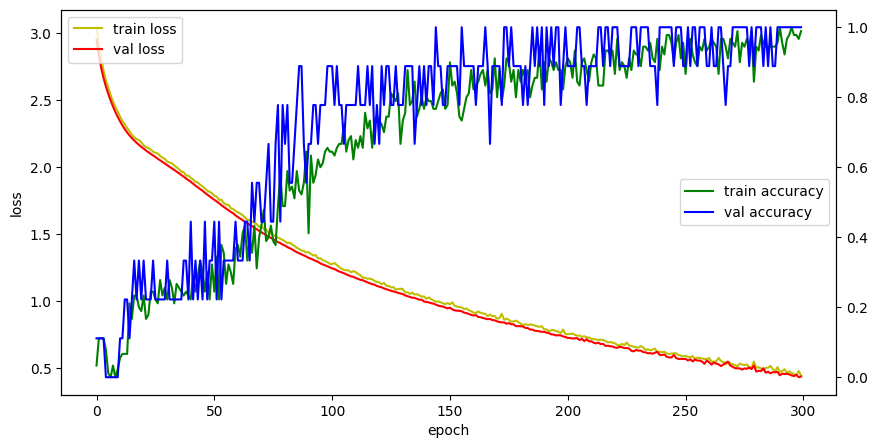

In [12]:
# 모델학습 과정 시각화
import matplotlib.pyplot as plt
fig, loss_x = plt.subplots(figsize=(10,5))
loss_x.plot(hist.history['loss'], 'y', label='train loss')
loss_x.plot(hist.history['val_loss'], 'r', label='val loss')
loss_x.set_xlabel('epoch')
loss_x.set_ylabel('loss')

acc_ax = loss_x.twinx() # loss_x와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_x.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [13]:
# 모델평가
score = model.evaluate(x_test, Y_test,
                      batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4354 - accuracy: 1.0000


In [14]:
score # loss, accuracy

[0.4354487955570221, 1.0]

In [16]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100, '%')

평가된 loss : 0.4354487955570221
평가된 accuracy : 100.0 %


# 7. 모델 사용하기

In [28]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 28ms/step


array([[3.35841207e-12, 3.74469336e-12, 6.93700761e-02, 2.35597827e-14,
        8.27557504e-01, 4.07937139e-13, 1.02338485e-01, 2.93709883e-11,
        7.32991030e-04, 2.89342198e-15, 9.05343597e-07, 8.33756350e-14,
        5.16171481e-11, 3.93071602e-14, 3.14765257e-15, 3.17043185e-13,
        1.25893412e-19, 1.57388261e-15, 9.60315124e-27]], dtype=float32)

In [29]:
# 분류분석의 예측은 predict 결과를 argmax()
model.predict(np.array([[2]])).argmax() # 가장 높은 확률의 인덱스 반환

1/1 [==============================] - 0s 26ms/step


4

In [30]:
# 4를 몇%로 예측했는지
H[0, H.argmax()]*100

82.75575041770935

# 8. 모델 저장하기

In [25]:
#model.save('model/02_deep.h5')  # tensorflow 10.5 이전 버전에서만 사용 가능
from tensorflow.keras.models import save_model  # tensorflow 모든 버전 사용가능
save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [31]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [ ]:
model2